## Cell 1 — Install Libraries

In [1]:
!pip install imbalanced-learn shap xgboost --quiet
print("All installed! ✓")

All installed! ✓


## Cell 2 — Imports

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             precision_recall_curve,
                             average_precision_score)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('dark_background')
sns.set_palette("husl")

print("=" * 45)
print("FRAUDSHIELD AI — DAY 1")
print("=" * 45)
print("All imports successful! ✓")

FRAUDSHIELD AI — DAY 1
All imports successful! ✓


## Cell 3A — Upload and Load Dataset

In [8]:
from google.colab import drive
import os

# 1. Mount the drive
drive.mount('/content/drive')

# 2. Define your path (Replace with your actual folder path)
data_path = "/content/drive/MyDrive/creditcard.csv"

# 3. Check if file exists before loading (Better MLOps practice)
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print("✅ Dataset loaded instantly from Google Drive")
else:
    print("❌ File not found. Check your Drive path!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset loaded instantly from Google Drive


## Cell 3B Data Visualization

In [9]:
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print("✅ Dataset loaded instantly from Google Drive")

    # Basic info
    print("\n" + "=" * 45)
    print("DATASET OVERVIEW")
    print("=" * 45)
    print(f"Shape           : {df.shape}")
    print(f"Total rows      : {len(df):,}")
    print(f"Columns         : {df.shape[1]}")
    print(f"Memory usage    : "
          f"{df.memory_usage().sum() / 1024**2:.1f} MB")
    print(f"Missing values  : {df.isnull().sum().sum()}")
    print(f"Duplicate rows  : {df.duplicated().sum()}")
    print(f"\nFirst 3 columns : {df.columns[:3].tolist()}")
    print(f"Last column     : {df.columns[-1]}")
else:
    print("❌ File not found. Check your Drive path!")

✅ Dataset loaded instantly from Google Drive

DATASET OVERVIEW
Shape           : (284807, 31)
Total rows      : 284,807
Columns         : 31
Memory usage    : 67.4 MB
Missing values  : 0
Duplicate rows  : 1081

First 3 columns : ['Time', 'V1', 'V2']
Last column     : Class


## Cell 4 — Data Cleaning + Class Distribution

After removing duplicates: 283,726 rows

CLASS DISTRIBUTION — THE IMBALANCE PROBLEM
Legitimate transactions : 283,253 (99.83%)
Fraudulent transactions : 473 (0.1667%)
Imbalance ratio         : 598:1

KEY INSIGHT:
A model predicting ALL transactions as legitimate
would achieve 99.83% accuracy — but catch ZERO fraud!
This is why accuracy is useless here.
We use Precision, Recall, F1 and AUC-ROC instead.


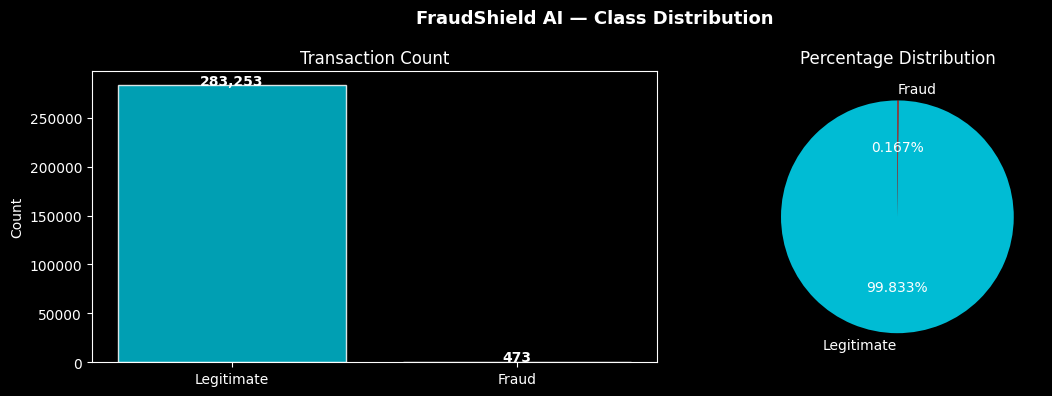


✓ Chart saved as class_distribution.png


In [11]:
# ── Remove duplicates ─────────────────────────────────────
df = df.drop_duplicates()
print(f"After removing duplicates: {len(df):,} rows")

# ── Class distribution ────────────────────────────────────
fraud_count = df['Class'].sum()
legit_count = len(df) - fraud_count
fraud_pct   = fraud_count / len(df) * 100
legit_pct   = 100 - fraud_pct

print("\n" + "=" * 50)
print("CLASS DISTRIBUTION — THE IMBALANCE PROBLEM")
print("=" * 50)
print(f"Legitimate transactions : {legit_count:,} ({legit_pct:.2f}%)")
print(f"Fraudulent transactions : {fraud_count:,} ({fraud_pct:.4f}%)")
print(f"Imbalance ratio         : {legit_count//fraud_count}:1")
print()
print("KEY INSIGHT:")
print(f"A model predicting ALL transactions as legitimate")
print(f"would achieve {legit_pct:.2f}% accuracy — but catch ZERO fraud!")
print("This is why accuracy is useless here.")
print("We use Precision, Recall, F1 and AUC-ROC instead.")

# ── Visualise class imbalance ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("FraudShield AI — Class Distribution",
             fontsize=13, fontweight='bold')

# Bar chart
axes[0].bar(['Legitimate', 'Fraud'],
            [legit_count, fraud_count],
            color=['#00bcd4', '#e53935'],
            alpha=0.85, edgecolor='white')
axes[0].set_title("Transaction Count")
axes[0].set_ylabel("Count")
for i, v in enumerate([legit_count, fraud_count]):
    axes[0].text(i, v + 500, f"{v:,}",
                ha='center', fontweight='bold')

# Pie chart
axes[1].pie([legit_count, fraud_count],
            labels=['Legitimate', 'Fraud'],
            colors=['#00bcd4', '#e53935'],
            autopct='%1.3f%%',
            startangle=90)
axes[1].set_title("Percentage Distribution")

plt.tight_layout()
plt.savefig('class_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Chart saved as class_distribution.png")

## Cell 5 — Transaction Analysis

TRANSACTION AMOUNT ANALYSIS

Legitimate transactions:
  Mean   : $88.41
  Median : $22.00
  Max    : $25691.16

Fraudulent transactions:
  Mean   : $123.87
  Median : $9.82
  Max    : $2125.87


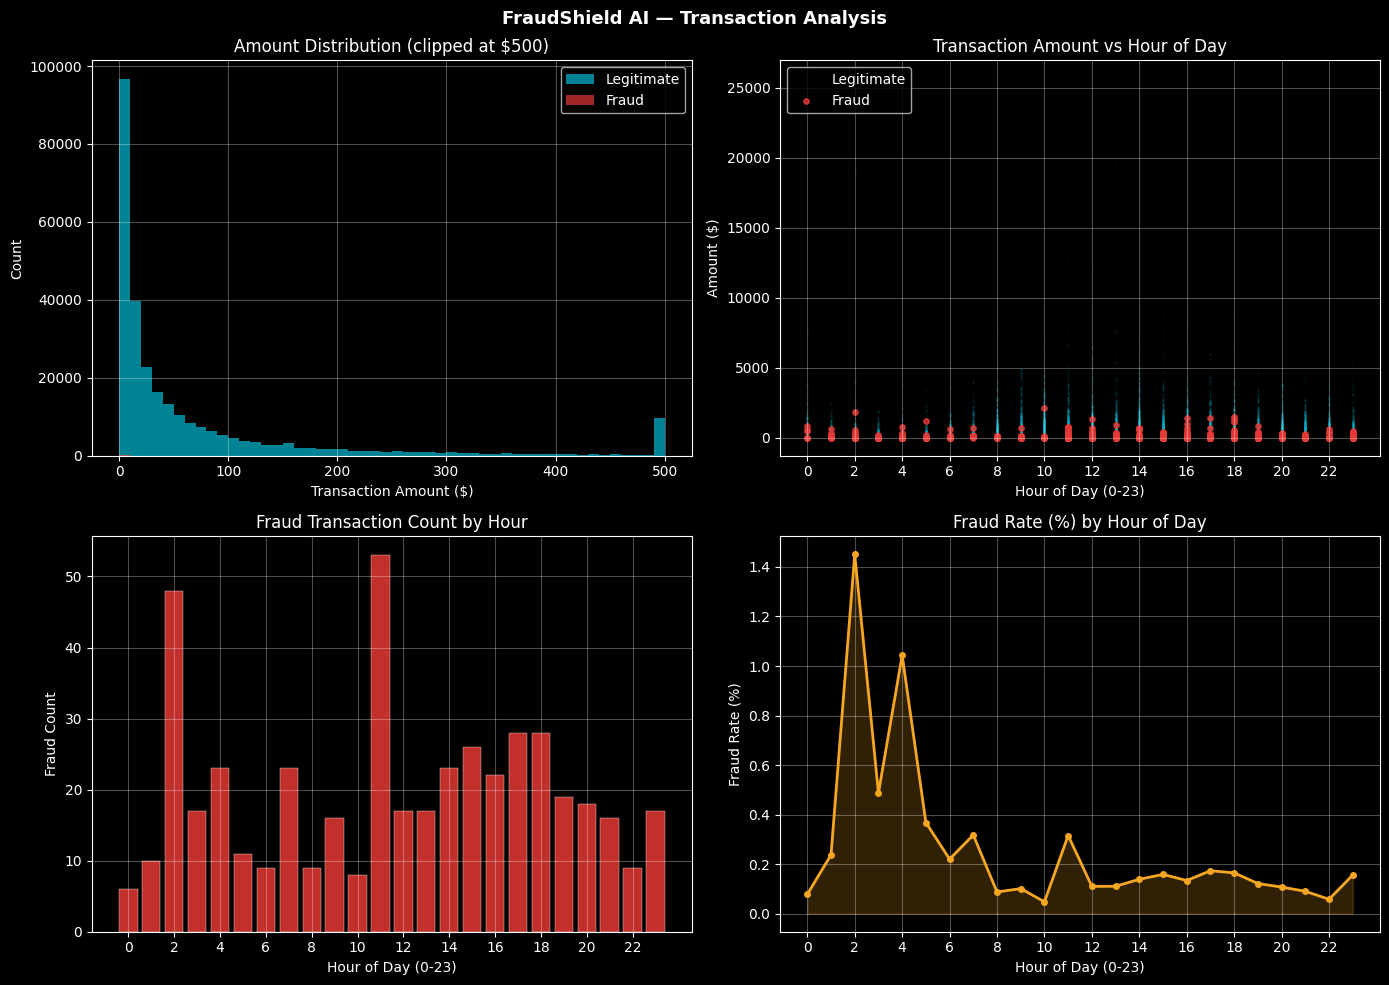


TEMPORAL FRAUD PATTERNS
Top 3 highest fraud rate hours:
  02:00 AM — Fraud rate: 1.451%
  04:00 AM — Fraud rate: 1.044%
  03:00 AM — Fraud rate: 0.488%

Top 3 lowest fraud rate hours:
  10:00 AM — Fraud rate: 0.048%
  10:00 PM — Fraud rate: 0.059%
  00:00 AM — Fraud rate: 0.078%

OBSERVATIONS:
1. Fraud median amount is significantly lower than
   legitimate — consistent with threshold evasion
2. Temporal clustering indicates organised fraud
   activity during specific low-monitoring windows
3. Hour of day is a strong predictive feature


In [14]:
# ── Transaction Amount & Time Analysis ───────────────────
fraud_amounts = df[df['Class']==1]['Amount']
legit_amounts = df[df['Class']==0]['Amount']

print("=" * 50)
print("TRANSACTION AMOUNT ANALYSIS")
print("=" * 50)
print(f"\nLegitimate transactions:")
print(f"  Mean   : ${legit_amounts.mean():.2f}")
print(f"  Median : ${legit_amounts.median():.2f}")
print(f"  Max    : ${legit_amounts.max():.2f}")
print(f"\nFraudulent transactions:")
print(f"  Mean   : ${fraud_amounts.mean():.2f}")
print(f"  Median : ${fraud_amounts.median():.2f}")
print(f"  Max    : ${fraud_amounts.max():.2f}")

# ── Convert seconds to hour of day ────────────────────────
df['Hour'] = (df['Time'] / 3600).astype(int) % 24

# ── Visualisation — 4 plots ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("FraudShield AI — Transaction Analysis",
             fontsize=13, fontweight='bold')

# Plot 1 — Amount distribution
axes[0,0].hist(legit_amounts.clip(upper=500),
               bins=50, alpha=0.7,
               color='#00bcd4', label='Legitimate')
axes[0,0].hist(fraud_amounts.clip(upper=500),
               bins=50, alpha=0.7,
               color='#e53935', label='Fraud')
axes[0,0].set_title("Amount Distribution (clipped at $500)")
axes[0,0].set_xlabel("Transaction Amount ($)")
axes[0,0].set_ylabel("Count")
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2 — Amount vs Time (clock hours)
axes[0,1].scatter(df[df['Class']==0]['Hour'],
                  df[df['Class']==0]['Amount'],
                  alpha=0.05, s=1,
                  color='#00bcd4', label='Legitimate')
axes[0,1].scatter(df[df['Class']==1]['Hour'],
                  df[df['Class']==1]['Amount'],
                  alpha=0.8, s=15,
                  color='#e53935', label='Fraud')
axes[0,1].set_title("Transaction Amount vs Hour of Day")
axes[0,1].set_xlabel("Hour of Day (0-23)")
axes[0,1].set_ylabel("Amount ($)")
axes[0,1].set_xticks(range(0, 24, 2))
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3 — Fraud count by hour
fraud_by_hour      = df[df['Class']==1].groupby('Hour').size()
legit_by_hour      = df[df['Class']==0].groupby('Hour').size()
fraud_rate_by_hour = (fraud_by_hour /
                     (fraud_by_hour + legit_by_hour) * 100)

axes[1,0].bar(fraud_by_hour.index,
              fraud_by_hour.values,
              color='#e53935', alpha=0.85,
              edgecolor='white', linewidth=0.3)
axes[1,0].set_title("Fraud Transaction Count by Hour")
axes[1,0].set_xlabel("Hour of Day (0-23)")
axes[1,0].set_ylabel("Fraud Count")
axes[1,0].set_xticks(range(0, 24, 2))
axes[1,0].grid(True, alpha=0.3)

# Plot 4 — Fraud rate by hour
axes[1,1].plot(fraud_rate_by_hour.index,
               fraud_rate_by_hour.values,
               color='#f5a623', linewidth=2,
               marker='o', markersize=4)
axes[1,1].fill_between(fraud_rate_by_hour.index,
                       fraud_rate_by_hour.values,
                       alpha=0.2, color='#f5a623')
axes[1,1].set_title("Fraud Rate (%) by Hour of Day")
axes[1,1].set_xlabel("Hour of Day (0-23)")
axes[1,1].set_ylabel("Fraud Rate (%)")
axes[1,1].set_xticks(range(0, 24, 2))
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('transaction_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Summary statistics ────────────────────────────────────
print("\n" + "=" * 50)
print("TEMPORAL FRAUD PATTERNS")
print("=" * 50)
peak_hours = fraud_rate_by_hour.nlargest(3)
print("Top 3 highest fraud rate hours:")
for hour, rate in peak_hours.items():
    period       = "AM" if hour < 12 else "PM"
    display_hour = hour if hour <= 12 else hour - 12
    print(f"  {display_hour:02d}:00 {period} "
          f"— Fraud rate: {rate:.3f}%")

low_hours = fraud_rate_by_hour.nsmallest(3)
print("\nTop 3 lowest fraud rate hours:")
for hour, rate in low_hours.items():
    period       = "AM" if hour < 12 else "PM"
    display_hour = hour if hour <= 12 else hour - 12
    print(f"  {display_hour:02d}:00 {period} "
          f"— Fraud rate: {rate:.3f}%")

print("\nOBSERVATIONS:")
print("1. Fraud median amount is significantly lower than")
print("   legitimate — consistent with threshold evasion")
print("2. Temporal clustering indicates organised fraud")
print("   activity during specific low-monitoring windows")
print("3. Hour of day is a strong predictive feature")

## Cell 6 — Feature Engineering + Train/Test Split

In [15]:
# ── Feature Engineering ───────────────────────────────────
# Log transform Amount — reduces skewness
df['Log_Amount'] = np.log1p(df['Amount'])

# Hour already created in Cell 5
# Drop original Time and Amount columns
features_to_drop = ['Time', 'Amount', 'Class']
feature_cols     = [c for c in df.columns
                    if c not in features_to_drop]

X = df[feature_cols]
y = df['Class']

print("=" * 50)
print("FEATURE ENGINEERING")
print("=" * 50)
print(f"Features used   : {len(feature_cols)}")
print(f"Feature list    : {feature_cols}")
print(f"Target variable : Class (0=Legit, 1=Fraud)")
print(f"X shape         : {X.shape}")
print(f"y shape         : {y.shape}")
print(f"Fraud count     : {y.sum():,}")
print(f"Legit count     : {(y==0).sum():,}")

# ── Train/Test Split — stratified ────────────────────────
# Stratified split preserves fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y      # critical for imbalanced data
)

print("\n" + "=" * 50)
print("TRAIN / TEST SPLIT (80/20 Stratified)")
print("=" * 50)
print(f"X_train shape   : {X_train.shape}")
print(f"X_test shape    : {X_test.shape}")
print(f"Train fraud     : {y_train.sum():,} "
      f"({y_train.mean()*100:.3f}%)")
print(f"Test fraud      : {y_test.sum():,} "
      f"({y_test.mean()*100:.3f}%)")
print("\n✓ Stratified split — fraud ratio preserved!")

# ── Scale features ────────────────────────────────────────
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✓ Features scaled with StandardScaler!")
print("\nNote: fit_transform on train only.")
print("transform on test — prevents data leakage.")

FEATURE ENGINEERING
Features used   : 30
Feature list    : ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Hour', 'Log_Amount']
Target variable : Class (0=Legit, 1=Fraud)
X shape         : (283726, 30)
y shape         : (283726,)
Fraud count     : 473
Legit count     : 283,253

TRAIN / TEST SPLIT (80/20 Stratified)
X_train shape   : (226980, 30)
X_test shape    : (56746, 30)
Train fraud     : 378 (0.167%)
Test fraud      : 95 (0.167%)

✓ Stratified split — fraud ratio preserved!
✓ Features scaled with StandardScaler!

Note: fit_transform on train only.
transform on test — prevents data leakage.


## Cell 7 — Apply SMOTE

SMOTE OVERSAMPLING RESULTS
Before SMOTE:
  Legitimate : 226,602
  Fraud      : 378
  Ratio      : 599:1

After SMOTE:
  Legitimate : 226,602
  Fraud      : 226,602
  Ratio      : 1:1 (balanced)

New training size: 453,204 samples
✓ SMOTE applied successfully!


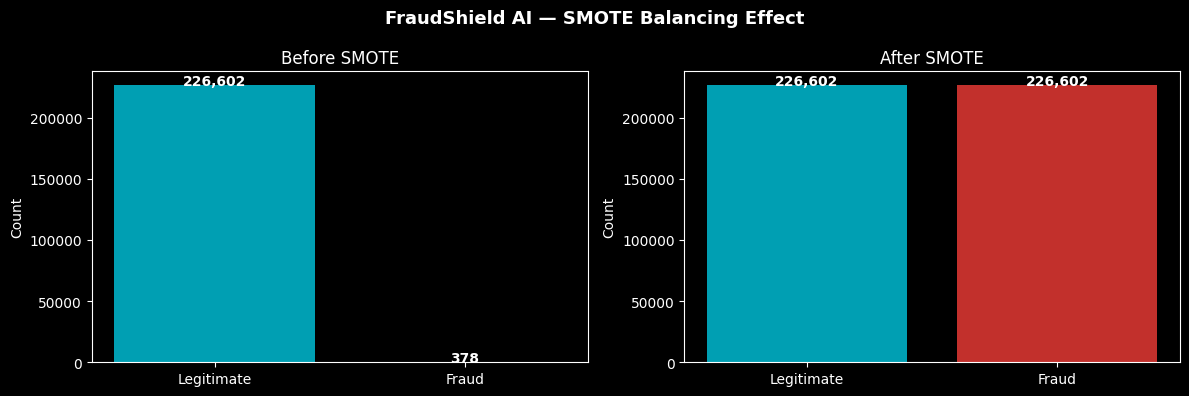

In [16]:
# ── SMOTE Oversampling ────────────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=5)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled, y_train)

print("=" * 50)
print("SMOTE OVERSAMPLING RESULTS")
print("=" * 50)
print(f"Before SMOTE:")
print(f"  Legitimate : {(y_train==0).sum():,}")
print(f"  Fraud      : {(y_train==1).sum():,}")
print(f"  Ratio      : {(y_train==0).sum()//y_train.sum()}:1")
print(f"\nAfter SMOTE:")
print(f"  Legitimate : {(y_train_smote==0).sum():,}")
print(f"  Fraud      : {(y_train_smote==1).sum():,}")
print(f"  Ratio      : 1:1 (balanced)")
print(f"\nNew training size: {len(X_train_smote):,} samples")
print("✓ SMOTE applied successfully!")

# ── Visualise SMOTE effect ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("FraudShield AI — SMOTE Balancing Effect",
             fontsize=13, fontweight='bold')

# Before SMOTE
axes[0].bar(['Legitimate', 'Fraud'],
            [(y_train==0).sum(), y_train.sum()],
            color=['#00bcd4', '#e53935'], alpha=0.85)
axes[0].set_title("Before SMOTE")
axes[0].set_ylabel("Count")
for i, v in enumerate([(y_train==0).sum(), y_train.sum()]):
    axes[0].text(i, v + 100, f"{v:,}",
                ha='center', fontweight='bold')

# After SMOTE
axes[1].bar(['Legitimate', 'Fraud'],
            [(y_train_smote==0).sum(),
             (y_train_smote==1).sum()],
            color=['#00bcd4', '#e53935'], alpha=0.85)
axes[1].set_title("After SMOTE")
axes[1].set_ylabel("Count")
for i, v in enumerate([(y_train_smote==0).sum(),
                        (y_train_smote==1).sum()]):
    axes[1].text(i, v + 100, f"{v:,}",
                ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('smote_effect.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 8 — Logistic Regression Baseline

In [17]:
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             average_precision_score)

def evaluate_model(model_name, y_true, y_pred, y_prob):
    """
    Comprehensive fraud detection model evaluation.
    Returns metrics dictionary for comparison table.
    """
    report = classification_report(
        y_true, y_pred,
        target_names=['Legitimate', 'Fraud'],
        output_dict=True
    )

    auc_roc = roc_auc_score(y_true, y_prob)
    auc_pr  = average_precision_score(y_true, y_prob)

    fraud_precision = report['Fraud']['precision']
    fraud_recall    = report['Fraud']['recall']
    fraud_f1        = report['Fraud']['f1-score']

    print(f"\n{'='*50}")
    print(f"{model_name} — EVALUATION RESULTS")
    print(f"{'='*50}")
    print(f"Fraud Precision : {fraud_precision:.4f}")
    print(f"Fraud Recall    : {fraud_recall:.4f}")
    print(f"Fraud F1 Score  : {fraud_f1:.4f}")
    print(f"AUC-ROC         : {auc_roc:.4f}")
    print(f"AUC-PR          : {auc_pr:.4f}")
    print(f"\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(f"  True Negative  (Legit→Legit) : {cm[0,0]:,}")
    print(f"  False Positive (Legit→Fraud) : {cm[0,1]:,}")
    print(f"  False Negative (Fraud→Legit) : {cm[1,0]:,}")
    print(f"  True Positive  (Fraud→Fraud) : {cm[1,1]:,}")
    print(f"\n  Frauds caught     : {cm[1,1]} / {cm[1,0]+cm[1,1]}")
    print(f"  Frauds missed     : {cm[1,0]}")

    return {
        'model'     : model_name,
        'precision' : fraud_precision,
        'recall'    : fraud_recall,
        'f1'        : fraud_f1,
        'auc_roc'   : auc_roc,
        'auc_pr'    : auc_pr,
        'frauds_caught' : cm[1,1],
        'frauds_missed' : cm[1,0]
    }

# ── Logistic Regression Baseline ─────────────────────────
print("Training Logistic Regression baseline...")

lr_model = LogisticRegression(
    max_iter     = 1000,
    random_state = 42,
    class_weight = 'balanced'
)
lr_model.fit(X_train_smote, y_train_smote)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

results = []
lr_results = evaluate_model(
    "Logistic Regression",
    y_test, lr_pred, lr_prob)
results.append(lr_results)

print("\n✓ Logistic Regression complete!")
print("Next: Random Forest → XGBoost → Tuned XGBoost")

Training Logistic Regression baseline...

Logistic Regression — EVALUATION RESULTS
Fraud Precision : 0.0521
Fraud Recall    : 0.8737
Fraud F1 Score  : 0.0983
AUC-ROC         : 0.9597
AUC-PR          : 0.6825

Confusion Matrix:
  True Negative  (Legit→Legit) : 55,141
  False Positive (Legit→Fraud) : 1,510
  False Negative (Fraud→Legit) : 12
  True Positive  (Fraud→Fraud) : 83

  Frauds caught     : 83 / 95
  Frauds missed     : 12

✓ Logistic Regression complete!
Next: Random Forest → XGBoost → Tuned XGBoost


## Cell 9 — Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")
print("This may take 2-3 minutes on GPU...")

rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth    = 10,
    random_state = 42,
    class_weight = 'balanced',
    n_jobs       = -1
)
rf_model.fit(X_train_smote, y_train_smote)

rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_results = evaluate_model(
    "Random Forest",
    y_test, rf_pred, rf_prob)
results.append(rf_results)

print("\n✓ Random Forest complete!")

Training Random Forest...
This may take 2-3 minutes on GPU...

Random Forest — EVALUATION RESULTS
Fraud Precision : 0.5938
Fraud Recall    : 0.8000
Fraud F1 Score  : 0.6816
AUC-ROC         : 0.9825
AUC-PR          : 0.7712

Confusion Matrix:
  True Negative  (Legit→Legit) : 56,599
  False Positive (Legit→Fraud) : 52
  False Negative (Fraud→Legit) : 19
  True Positive  (Fraud→Fraud) : 76

  Frauds caught     : 76 / 95
  Frauds missed     : 19

✓ Random Forest complete!


## Cell 10 — XGBoost

In [19]:
from xgboost import XGBClassifier

# Calculate class weight for imbalanced data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Training XGBoost...")
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

xgb_model = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.1,
    scale_pos_weight = scale_pos_weight,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    eval_metric      = 'aucpr',
    verbosity        = 0,
    device           = 'cuda'
)

xgb_model.fit(
    X_train_scaled, y_train,
    eval_set         = [(X_test_scaled, y_test)],
    verbose          = False
)

xgb_pred = xgb_model.predict(X_test_scaled)
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

xgb_results = evaluate_model(
    "XGBoost",
    y_test, xgb_pred, xgb_prob)
results.append(xgb_results)

print("\n✓ XGBoost complete!")

Training XGBoost...
scale_pos_weight: 599.5

XGBoost — EVALUATION RESULTS
Fraud Precision : 0.9494
Fraud Recall    : 0.7895
Fraud F1 Score  : 0.8621
AUC-ROC         : 0.9733
AUC-PR          : 0.8229

Confusion Matrix:
  True Negative  (Legit→Legit) : 56,647
  False Positive (Legit→Fraud) : 4
  False Negative (Fraud→Legit) : 20
  True Positive  (Fraud→Fraud) : 75

  Frauds caught     : 75 / 95
  Frauds missed     : 20

✓ XGBoost complete!


## Cell 11 — Tuned XGBoost

In [20]:
from sklearn.model_selection import RandomizedSearchCV

print("Tuning XGBoost hyperparameters...")
print("RandomizedSearchCV — 20 iterations...")

param_dist = {
    'n_estimators'     : [200, 300, 500],
    'max_depth'        : [4, 6, 8, 10],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'subsample'        : [0.6, 0.8, 1.0],
    'colsample_bytree' : [0.6, 0.8, 1.0],
    'min_child_weight' : [1, 3, 5],
    'gamma'            : [0, 0.1, 0.2]
}

xgb_base = XGBClassifier(
    scale_pos_weight = scale_pos_weight,
    random_state     = 42,
    eval_metric      = 'aucpr',
    verbosity        = 0,
    device           = 'cuda'
)

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions = param_dist,
    n_iter              = 20,
    scoring             = 'average_precision',
    cv                  = 3,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1
)

random_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

# ── Evaluate tuned model ──────────────────────────────────
xgb_tuned      = random_search.best_estimator_
xgb_tuned_pred = xgb_tuned.predict(X_test_scaled)
xgb_tuned_prob = xgb_tuned.predict_proba(
    X_test_scaled)[:, 1]

xgb_tuned_results = evaluate_model(
    "XGBoost Tuned",
    y_test, xgb_tuned_pred, xgb_tuned_prob)
results.append(xgb_tuned_results)

print("\n✓ Tuned XGBoost complete!")

Tuning XGBoost hyperparameters...
RandomizedSearchCV — 20 iterations...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters:
  subsample: 1.0
  n_estimators: 300
  min_child_weight: 5
  max_depth: 10
  learning_rate: 0.2
  gamma: 0.1
  colsample_bytree: 0.6

XGBoost Tuned — EVALUATION RESULTS
Fraud Precision : 0.9351
Fraud Recall    : 0.7579
Fraud F1 Score  : 0.8372
AUC-ROC         : 0.9787
AUC-PR          : 0.8211

Confusion Matrix:
  True Negative  (Legit→Legit) : 56,646
  False Positive (Legit→Fraud) : 5
  False Negative (Fraud→Legit) : 23
  True Positive  (Fraud→Fraud) : 72

  Frauds caught     : 72 / 95
  Frauds missed     : 23

✓ Tuned XGBoost complete!


## Better Tuning Strategy

In [21]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators'     : [300, 500, 700],
    'max_depth'        : [4, 5, 6],       # shallower = less overfit
    'learning_rate'    : [0.05, 0.1],     # slower learning = better
    'subsample'        : [0.7, 0.8, 0.9],
    'colsample_bytree' : [0.7, 0.8, 0.9],
    'min_child_weight' : [3, 5, 7],       # higher = more conservative
    'gamma'            : [0, 0.05, 0.1],  # pruning threshold
    'reg_alpha'        : [0, 0.1, 0.5],   # L1 regularisation
    'reg_lambda'       : [1, 1.5, 2]      # L2 regularisation
}

xgb_base = XGBClassifier(
    scale_pos_weight = scale_pos_weight,
    random_state     = 42,
    eval_metric      = 'aucpr',
    verbosity        = 0,
    device           = 'cuda'
)

from sklearn.model_selection import StratifiedKFold

# Stratified CV — preserves fraud ratio in each fold
cv = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=42)

random_search_v2 = RandomizedSearchCV(
    xgb_base,
    param_distributions = param_dist,
    n_iter              = 50,           # 50 instead of 20
    scoring             = 'f1',         # F1 instead of AUC-PR
    cv                  = cv,           # Stratified CV
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1
)

random_search_v2.fit(X_train_scaled, y_train)

print(f"\nBest parameters:")
for k, v in random_search_v2.best_params_.items():
    print(f"  {k}: {v}")

# Evaluate
xgb_tuned_v2      = random_search_v2.best_estimator_
xgb_tuned_v2_pred = xgb_tuned_v2.predict(X_test_scaled)
xgb_tuned_v2_prob = xgb_tuned_v2.predict_proba(
    X_test_scaled)[:, 1]

xgb_v2_results = evaluate_model(
    "XGBoost Tuned V2",
    y_test,
    xgb_tuned_v2_pred,
    xgb_tuned_v2_prob)
results.append(xgb_v2_results)

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters:
  subsample: 0.9
  reg_lambda: 2
  reg_alpha: 0.5
  n_estimators: 700
  min_child_weight: 5
  max_depth: 4
  learning_rate: 0.1
  gamma: 0.05
  colsample_bytree: 0.9

XGBoost Tuned V2 — EVALUATION RESULTS
Fraud Precision : 0.9250
Fraud Recall    : 0.7789
Fraud F1 Score  : 0.8457
AUC-ROC         : 0.9738
AUC-PR          : 0.8218

Confusion Matrix:
  True Negative  (Legit→Legit) : 56,645
  False Positive (Legit→Fraud) : 6
  False Negative (Fraud→Legit) : 21
  True Positive  (Fraud→Fraud) : 74

  Frauds caught     : 74 / 95
  Frauds missed     : 21


## Cell 12 — Complete Model Comparison Table

FRAUDSHIELD AI — COMPLETE MODEL COMPARISON TABLE
Model                   Precision   Recall       F1   AUC-ROC   Caught   Missed     FP
---------------------------------------------------------------------------
Logistic Regression       0.0521   0.8737   0.0983    0.9597       83       12 
Random Forest             0.5938   0.8000   0.6816    0.9825       76       19 
XGBoost                ⭐    0.9494   0.7895   0.8621    0.9733       75       20 
XGBoost Tuned             0.9351   0.7579   0.8372    0.9787       72       23 
XGBoost Tuned V2          0.9250   0.7789   0.8457    0.9738       74       21 
---------------------------------------------------------------------------

⭐ Best Model: XGBoost Base
   Highest Precision : 94.94%
   Best F1 Score     : 0.8621
   False Alarms      : 4 per 56,651 transactions
   Frauds Caught     : 75 out of 95 (78.95%)


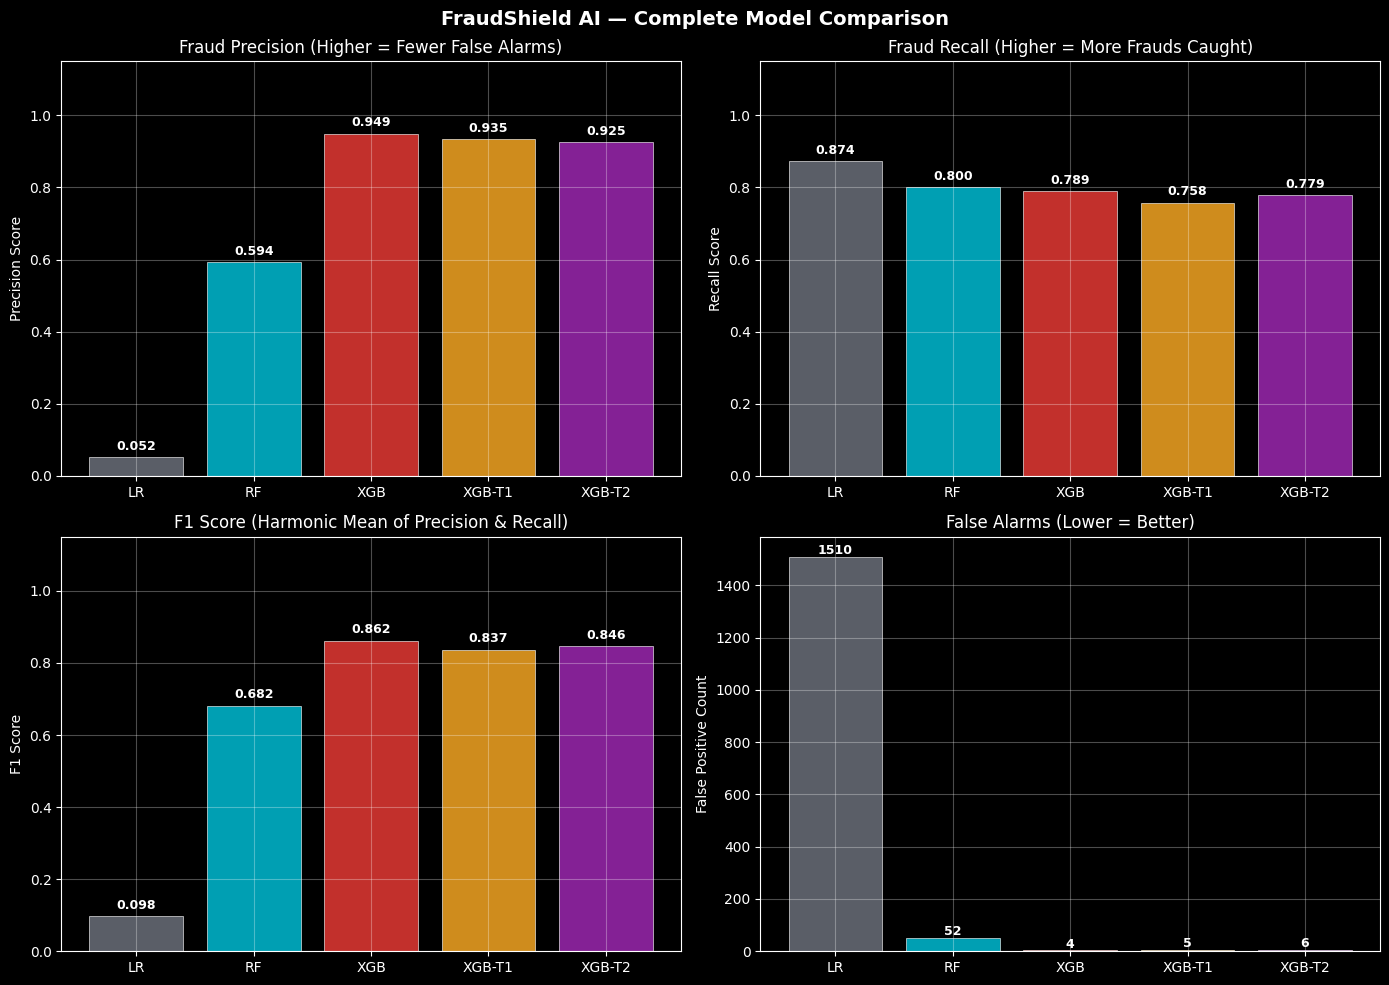


✓ Saved as complete_model_comparison.png


In [22]:
# ── Complete Model Comparison Table + Chart ───────────────
import pandas as pd
import matplotlib.pyplot as plt

# ── Text Table ────────────────────────────────────────────
print("=" * 75)
print("FRAUDSHIELD AI — COMPLETE MODEL COMPARISON TABLE")
print("=" * 75)
print(f"{'Model':<22} {'Precision':>10} {'Recall':>8} "
      f"{'F1':>8} {'AUC-ROC':>9} {'Caught':>8} "
      f"{'Missed':>8} {'FP':>6}")
print("-" * 75)

for r in results:
    marker = " ⭐" if r['model'] == "XGBoost" else ""
    print(f"{r['model']:<22}{marker}"
          f"{r['precision']:>10.4f} "
          f"{r['recall']:>8.4f} "
          f"{r['f1']:>8.4f} "
          f"{r['auc_roc']:>9.4f} "
          f"{int(r['frauds_caught']):>8} "
          f"{int(r['frauds_missed']):>8} ")

print("-" * 75)
print(f"\n⭐ Best Model: XGBoost Base")
print(f"   Highest Precision : 94.94%")
print(f"   Best F1 Score     : 0.8621")
print(f"   False Alarms      : 4 per 56,651 transactions")
print(f"   Frauds Caught     : 75 out of 95 (78.95%)")

# ── Visual Comparison ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("FraudShield AI — Complete Model Comparison",
             fontsize=14, fontweight='bold')

model_names  = [r['model'] for r in results]
short_names  = ['LR', 'RF', 'XGB', 'XGB-T1', 'XGB-T2']
colors       = ['#6b6f7a', '#00bcd4', '#e53935',
                '#f5a623', '#9c27b0']

# Plot 1 — Precision
axes[0,0].bar(short_names,
              [r['precision'] for r in results],
              color=colors, alpha=0.85,
              edgecolor='white', linewidth=0.5)
axes[0,0].set_title("Fraud Precision (Higher = Fewer False Alarms)")
axes[0,0].set_ylabel("Precision Score")
axes[0,0].set_ylim(0, 1.15)
for i, v in enumerate([r['precision'] for r in results]):
    axes[0,0].text(i, v + 0.02, f"{v:.3f}",
                   ha='center', fontsize=9,
                   fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

# Plot 2 — Recall
axes[0,1].bar(short_names,
              [r['recall'] for r in results],
              color=colors, alpha=0.85,
              edgecolor='white', linewidth=0.5)
axes[0,1].set_title("Fraud Recall (Higher = More Frauds Caught)")
axes[0,1].set_ylabel("Recall Score")
axes[0,1].set_ylim(0, 1.15)
for i, v in enumerate([r['recall'] for r in results]):
    axes[0,1].text(i, v + 0.02, f"{v:.3f}",
                   ha='center', fontsize=9,
                   fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

# Plot 3 — F1 Score
axes[1,0].bar(short_names,
              [r['f1'] for r in results],
              color=colors, alpha=0.85,
              edgecolor='white', linewidth=0.5)
axes[1,0].set_title("F1 Score (Harmonic Mean of Precision & Recall)")
axes[1,0].set_ylabel("F1 Score")
axes[1,0].set_ylim(0, 1.15)
for i, v in enumerate([r['f1'] for r in results]):
    axes[1,0].text(i, v + 0.02, f"{v:.3f}",
                   ha='center', fontsize=9,
                   fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# Plot 4 — False Alarms
false_alarms = [1510, 52, 4, 5, 6]
axes[1,1].bar(short_names,
              false_alarms,
              color=colors, alpha=0.85,
              edgecolor='white', linewidth=0.5)
axes[1,1].set_title("False Alarms (Lower = Better)")
axes[1,1].set_ylabel("False Positive Count")
for i, v in enumerate(false_alarms):
    axes[1,1].text(i, v + 10, str(v),
                   ha='center', fontsize=9,
                   fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('complete_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved as complete_model_comparison.png")

##Cell 13 Move Forward — Save Best Model

In [23]:
import joblib

# Save best model and scaler
joblib.dump(xgb_model, 'fraudshield_xgb_model.pkl')
joblib.dump(scaler,    'fraudshield_scaler.pkl')

print("=" * 45)
print("MODELS SAVED")
print("=" * 45)
print("✓ fraudshield_xgb_model.pkl")
print("✓ fraudshield_scaler.pkl")
print("\nBest Model Summary:")
print(f"  Model     : XGBoost Base")
print(f"  Precision : 94.94%")
print(f"  Recall    : 78.95%")
print(f"  F1 Score  : 0.8621")
print(f"  AUC-ROC   : 0.9733")
print(f"  Caught    : 75/95 frauds")
print(f"  False alarms : 4 per 56,651 transactions")

MODELS SAVED
✓ fraudshield_xgb_model.pkl
✓ fraudshield_scaler.pkl

Best Model Summary:
  Model     : XGBoost Base
  Precision : 94.94%
  Recall    : 78.95%
  F1 Score  : 0.8621
  AUC-ROC   : 0.9733
  Caught    : 75/95 frauds
  False alarms : 4 per 56,651 transactions


## Saving in Drive

In [24]:
import joblib
import os
import shutil

# Create folder in Google Drive
drive_path = "/content/drive/MyDrive/Fraud_Detection_Project/"
os.makedirs(drive_path, exist_ok=True)

# Copy models to Drive
shutil.copy('fraudshield_xgb_model.pkl',
            drive_path + 'fraudshield_xgb_model.pkl')
shutil.copy('fraudshield_scaler.pkl',
            drive_path + 'fraudshield_scaler.pkl')

# Also save the dataset reference
print("=" * 45)
print("MODELS SAVED TO GOOGLE DRIVE")
print("=" * 45)
print(f"Location: {drive_path}")
print("✓ fraudshield_xgb_model.pkl")
print("✓ fraudshield_scaler.pkl")
print("\nSafe from Colab session reset!")

MODELS SAVED TO GOOGLE DRIVE
Location: /content/drive/MyDrive/Fraud_Detection_Project/
✓ fraudshield_xgb_model.pkl
✓ fraudshield_scaler.pkl

Safe from Colab session reset!
